In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#import importlib
#importlib.reload(plt)
import scipy.stats as stats
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler

def eda(df):
    print("Dimensions of the dataset: ")
    print(df.shape)
    print("Here are all the columns present in the dataframe: ")
    for i in df.columns:
        print(i)
    print("Number of missing values in each column: ")
    x = df.columns
    y = df.isnull().sum()
    plt.xlabel("Columns")
    plt.ylabel("No of missing values")
    plt.title("Number of Missing values in the dataset")
    plt.xticks(rotation=45, ha='right')
    plt.bar(x,y)
    plt.show()
    for i in x:
        if df[i].isna().sum() > len(df[i]) * 0.5:
            print("This feature:" + i + "has more than 50% missing values")
            df = df.drop(columns = [i])
    num_cols = df.select_dtypes(include=['number']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    for j in num_cols:
        print("These are the graphs relating to feature:", i)
        df[j].plot(kind = "hist", bins=30)
        plt.title(j)
        plt.show()
        df[j].plot(kind = "kde")
        plt.title(j)
        plt.show()
        df.boxplot(column=[j])
        plt.title(j)
        plt.show()
        stats.probplot(df[j], dist="norm", plot=plt)
        plt.title(j)
        plt.show()
        print("What task do you want to perform: ")
        print("1. Log transformation")
        print("2. Standard scaling")
        print("3. Do nothing")
        ch = int(input("Your choice: "))
        if ch == 1:
            df[j] = np.log1p(df[j])
        if ch == 2:
            scaler = StandardScaler()
            df[j] = scaler.fit_transform(df[[j]])
    print("Graphs of all the categorical features:")
    for k in cat_cols:
        counts = df[k].value_counts()
        labels = counts.index
        plt.figure(figsize=(6, 4))
        sns.countplot(data=df, x=k, order=counts.index, palette='viridis')
        plt.title(f"Count Plot of {k}")
        plt.xlabel(k)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        plt.figure(figsize=(5, 5))
        plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
        plt.title(f"Pie Chart of {k}")
        plt.tight_layout()
        plt.show()
    for z in num_cols:
        z_score_out = zscore(df[z])
        outliers_z = df[abs(z_score_out) > 3]
        Q1 = df[z].quantile(0.25)
        Q3 = df[z].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers_iqr = df[
            (df[z] < lower) |
            (df[z] > upper)
        ]
        outliers = pd.merge(outliers_iqr,outliers_z)
        print("For the feature:" , z, ", These are the outlirers: ")
        print(outliers)
        print("What should we do with the outliers?")
        print("1. Impute")
        print("2. Delete")
        print("3. Ignore")
        ch = int(input("Enter option: "))
        if ch == 1:
            clean_data = df[~df.index.isin(outliers.index)]
            median_val = clean_data[z].median()
            df.loc[outliers.index, z] = median_val
            print(f"Outliers in '{z}' successfully imputed with median value: {median_val}\n")
        elif ch == 2:
            df = df.drop(index=list(outliers.index))
        else:
            pass







Dimensions of the dataset: 
(367, 12)
Here are all the columns present in the dataframe: 
Loan_ID
Gender
Married
Dependents
Education
Self_Employed
ApplicantIncome
CoapplicantIncome
LoanAmount
Loan_Amount_Term
Credit_History
Property_Area
Number of missing values in each column: 


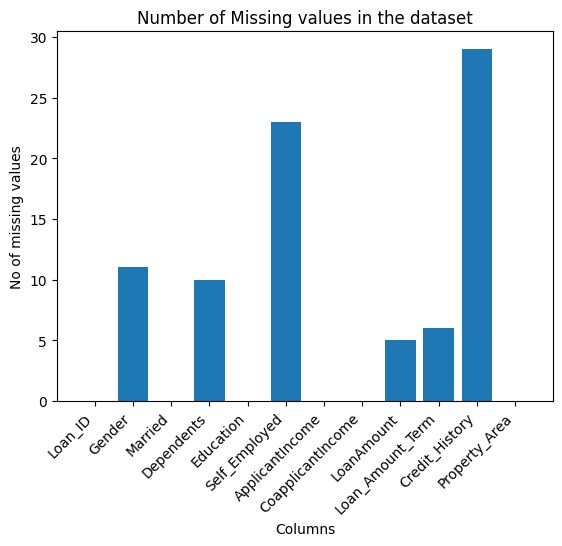

These are the graphs relating to feature: Property_Area


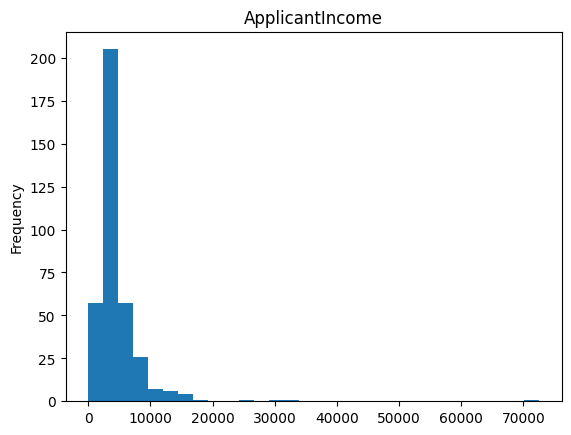

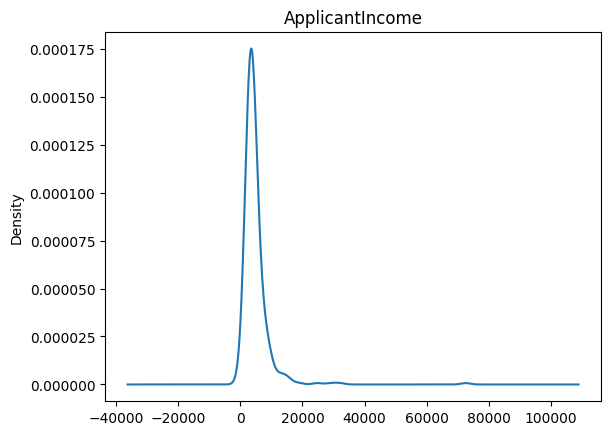

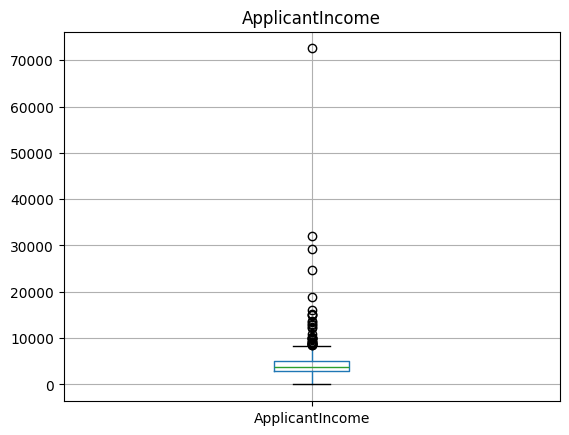

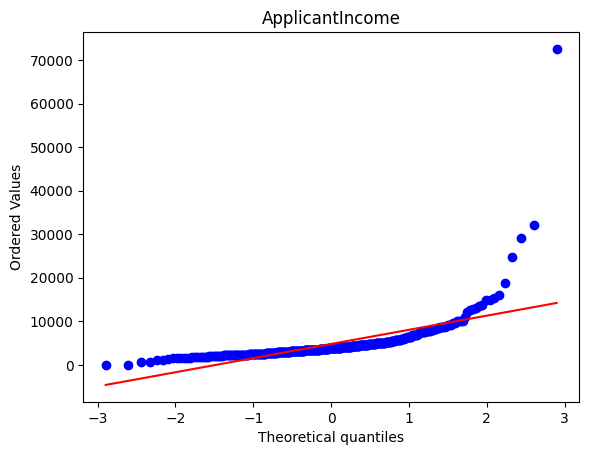

What task do you want to perform: 
1. Log transformation
2. Standard scaling
3. Do nothing
These are the graphs relating to feature: Property_Area


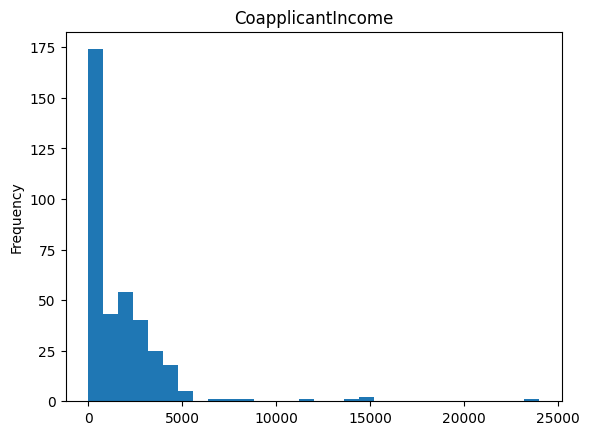

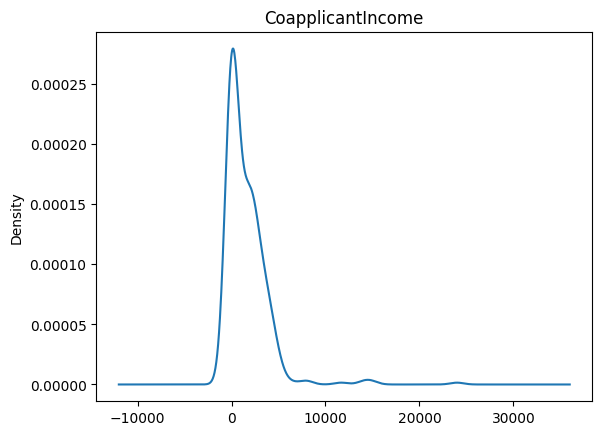

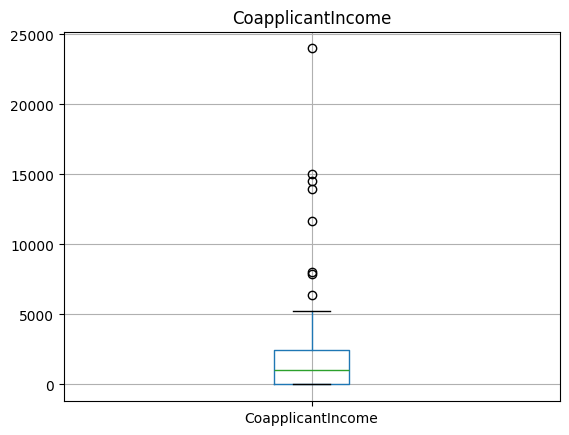

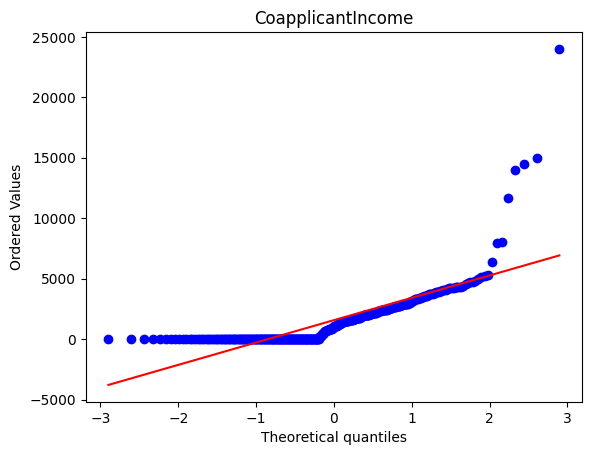

What task do you want to perform: 
1. Log transformation
2. Standard scaling
3. Do nothing
These are the graphs relating to feature: Property_Area


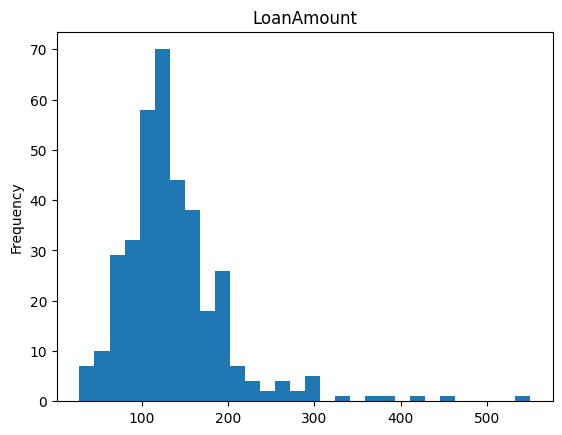

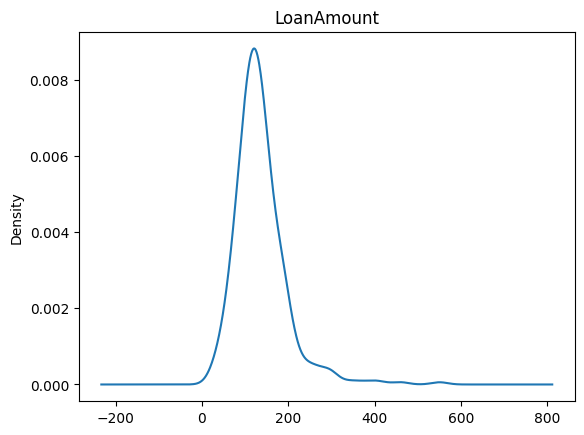

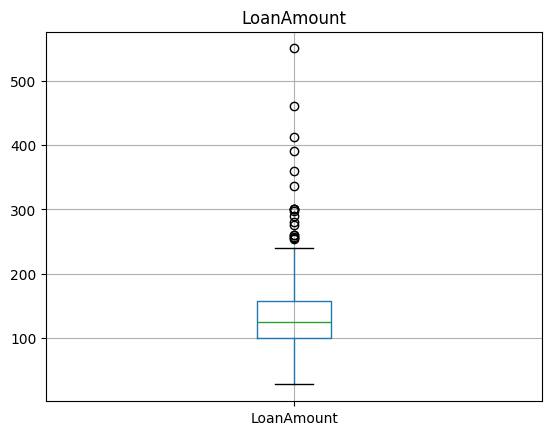

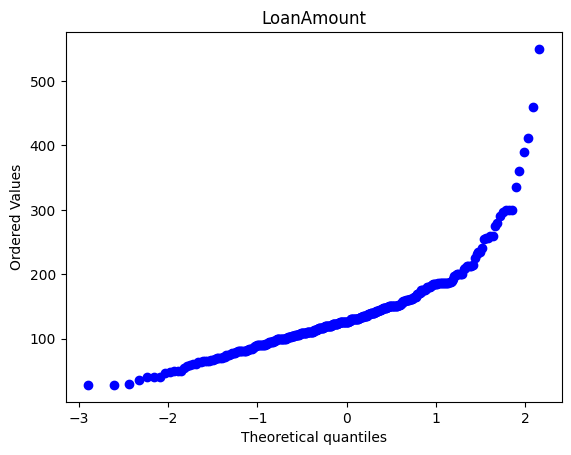

What task do you want to perform: 
1. Log transformation
2. Standard scaling
3. Do nothing
These are the graphs relating to feature: Property_Area


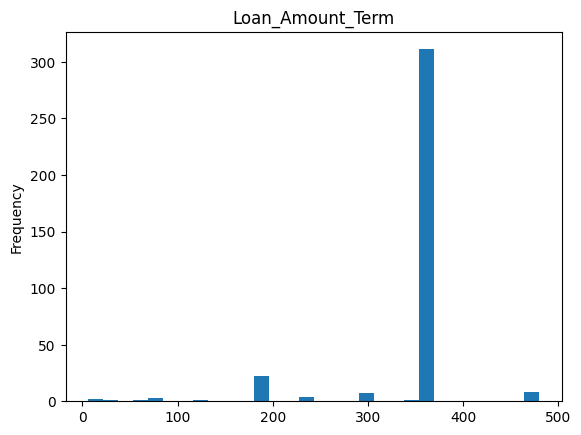

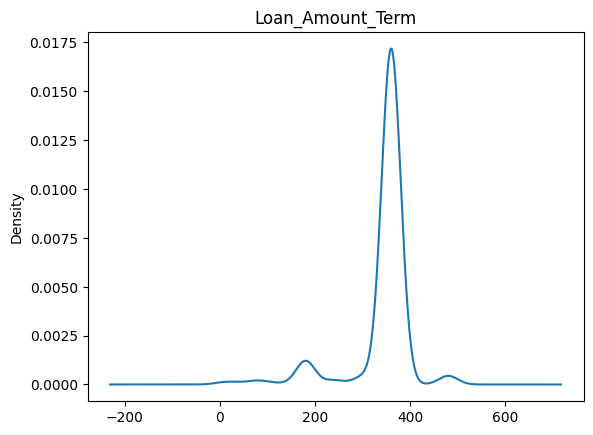

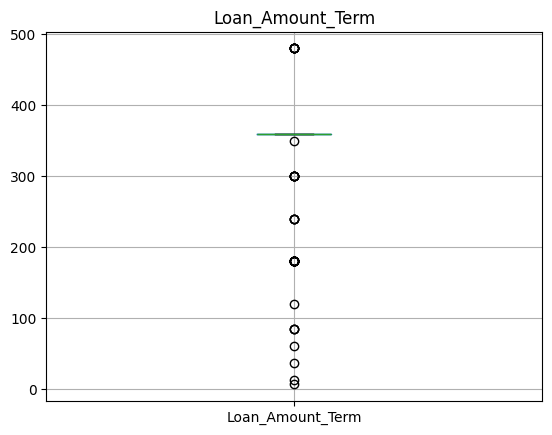

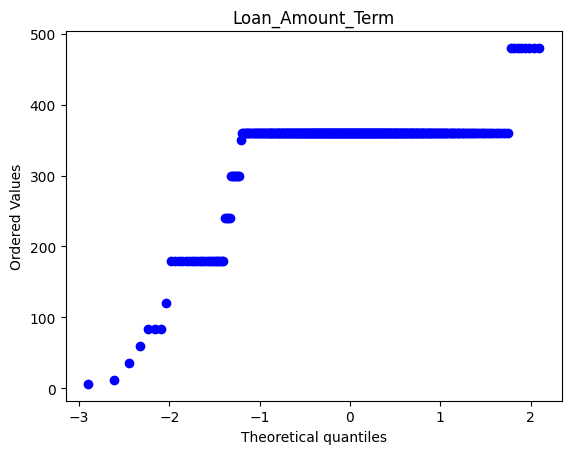

What task do you want to perform: 
1. Log transformation
2. Standard scaling
3. Do nothing
These are the graphs relating to feature: Property_Area


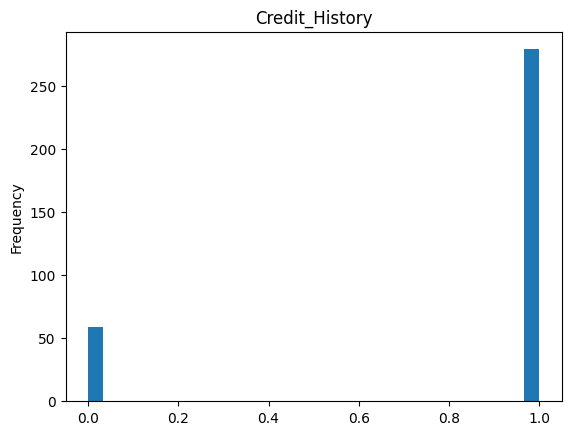

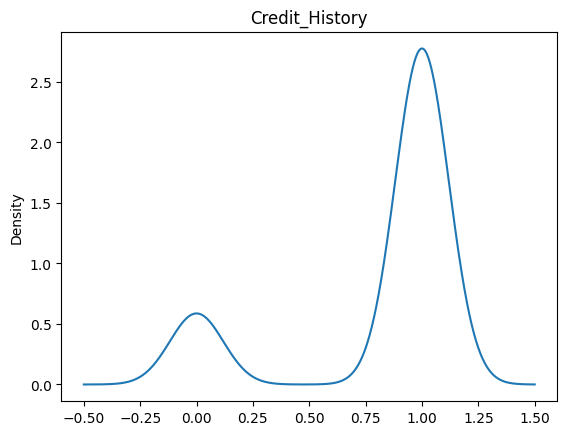

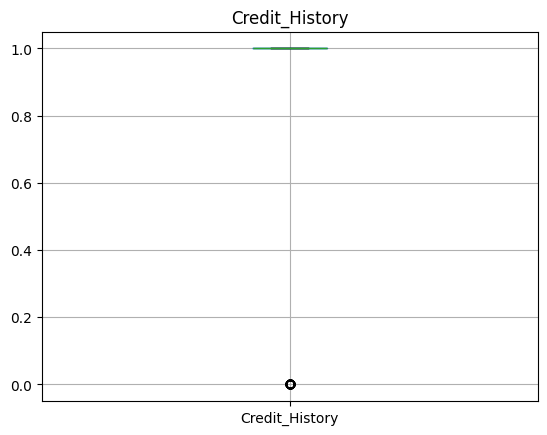

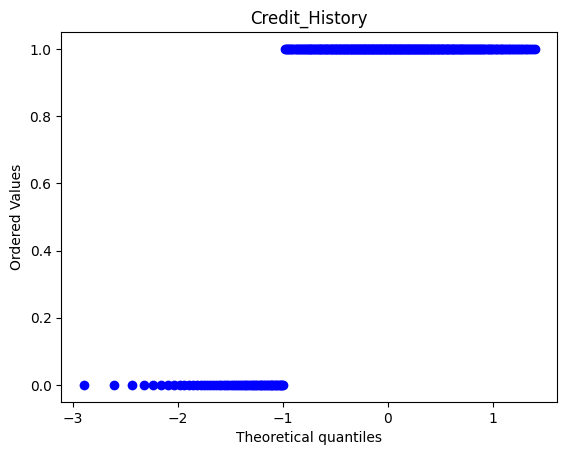

What task do you want to perform: 
1. Log transformation
2. Standard scaling
3. Do nothing
Graphs of all the categorical features:


C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_21896\3614111991.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


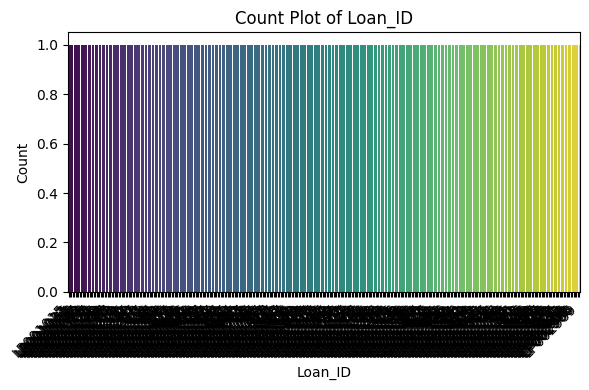

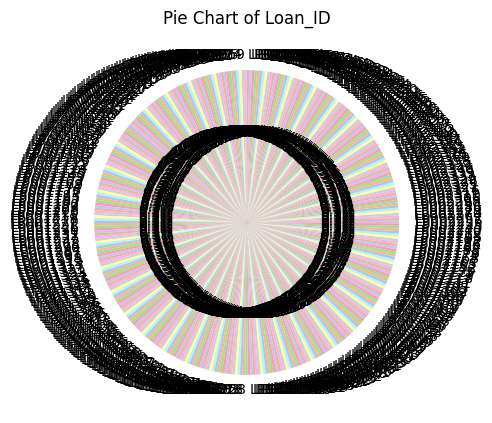

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_21896\3614111991.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


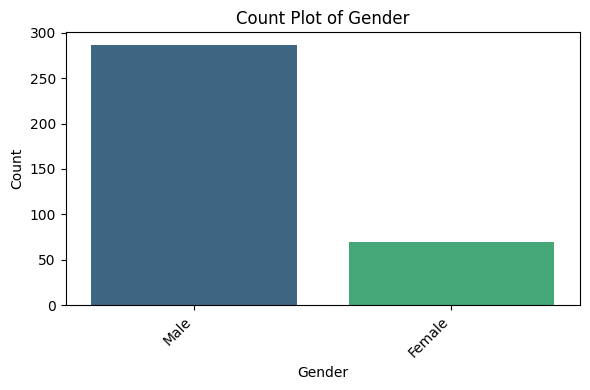

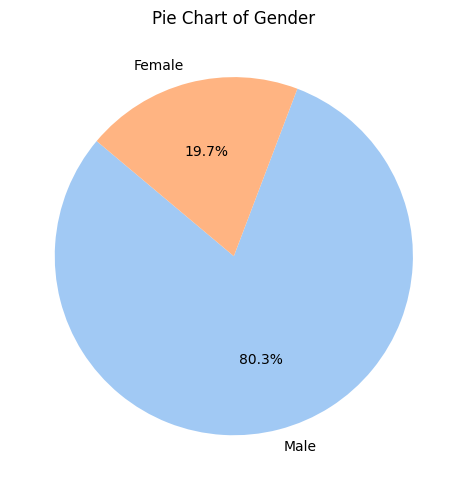

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_21896\3614111991.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


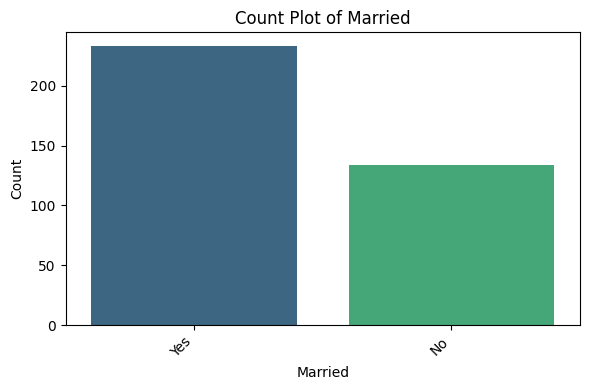

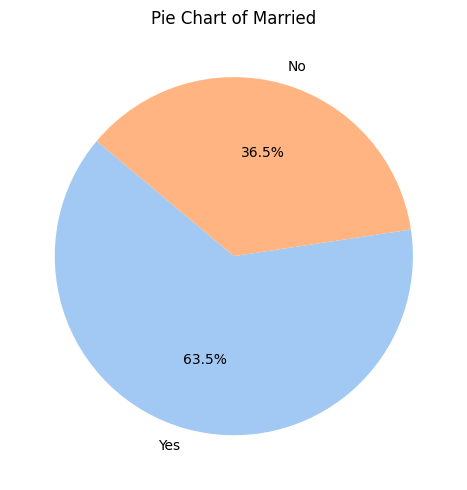

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_21896\3614111991.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


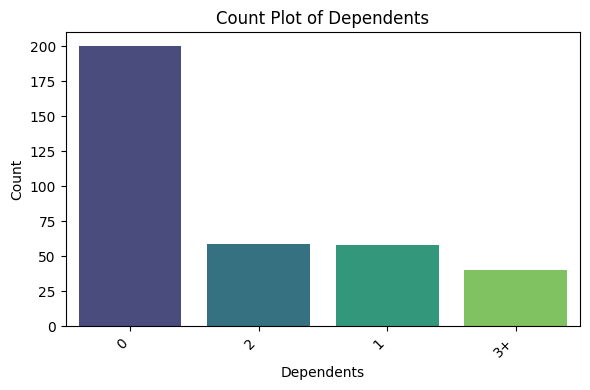

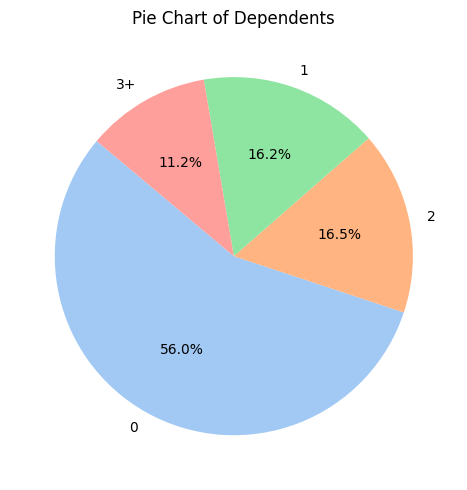

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_21896\3614111991.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


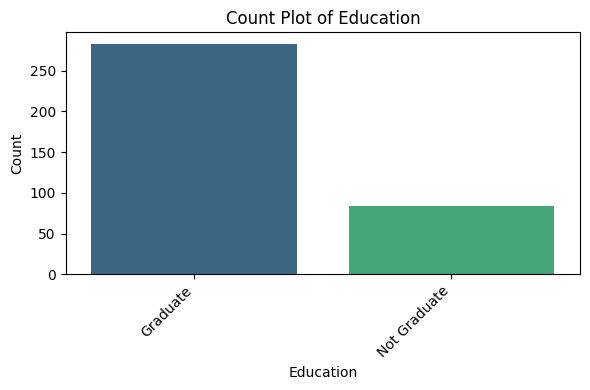

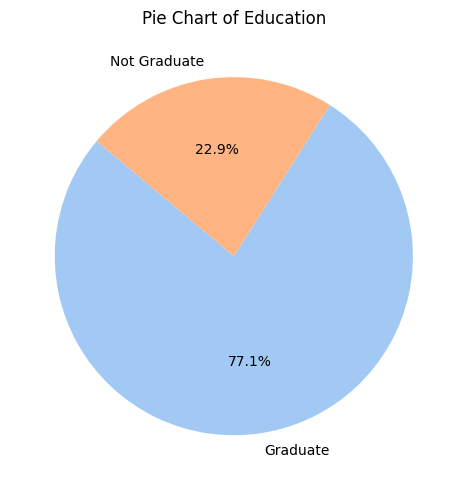

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_21896\3614111991.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


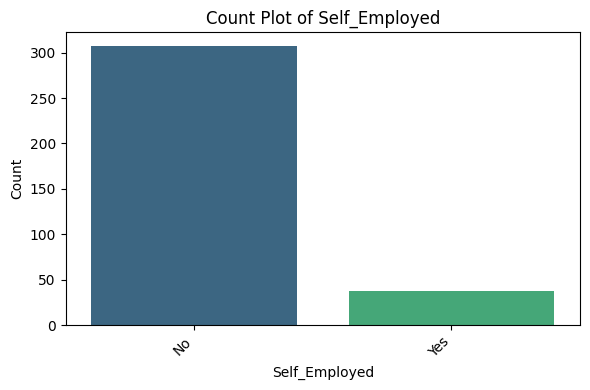

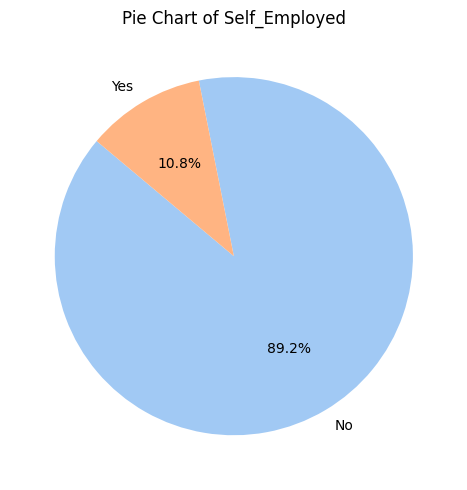

C:\Users\Logesh SD\AppData\Local\Temp\ipykernel_21896\3614111991.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=k, order=counts.index, palette='viridis')


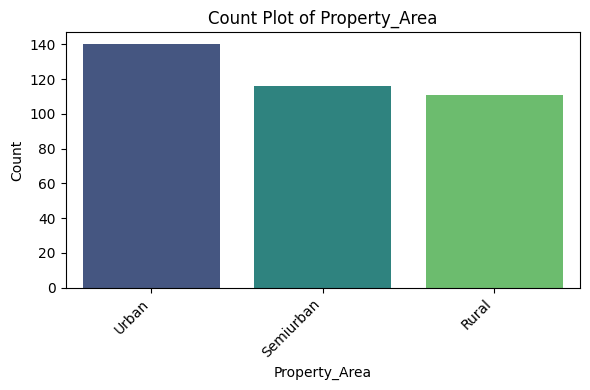

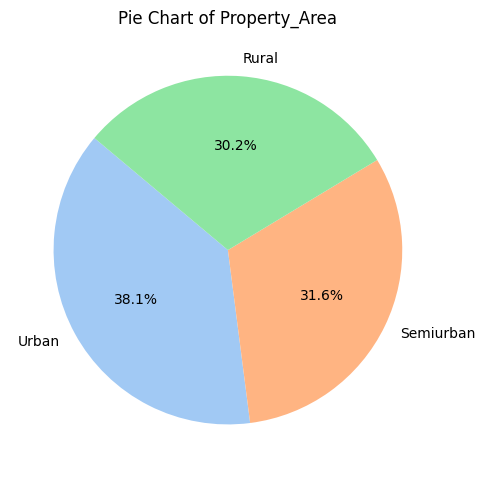

For the feature: ApplicantIncome , These are the outlirers: 
    Loan_ID Gender Married Dependents Education Self_Employed  \
0  LP001428   Male     Yes         3+  Graduate            No   
1  LP001791   Male     Yes          0  Graduate           Yes   
2  LP002485   Male      No          1  Graduate            No   
3  LP002553    NaN      No          0  Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0            72529                  0       360.0             360.0   
1            32000                  0       550.0             360.0   
2            24797                  0       240.0             360.0   
3            29167                  0       185.0             360.0   

   Credit_History Property_Area  
0             1.0         Urban  
1             NaN     Semiurban  
2             1.0     Semiurban  
3             1.0     Semiurban  
For the feature: CoapplicantIncome , These are the outlirers: 
    Loan_ID  Gender Marr

In [10]:
data = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')
eda(data)